# Customer Churn Prediction using Machine Learning

Customer churn prediction helps companies identify customers who are likely to stop using their services.

In this project we analyze telecom customer data and build machine learning models to predict churn.

Models used:
- Logistic Regression
- Random Forest
- XGBoost

In [50]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

from imblearn.over_sampling import SMOTE

import joblib
import os

In [51]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [52]:
print("Dataset shape:", df.shape)

df.info()

Dataset shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling

In [53]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df = df.dropna()

df = df.drop("customerID", axis=1)

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (7032, 20)


In [54]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

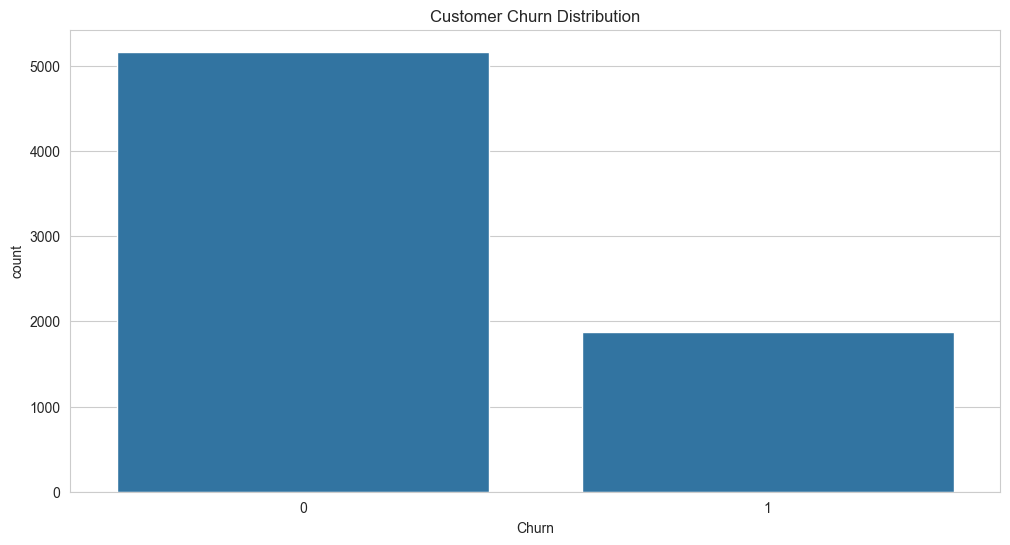

In [55]:
os.makedirs("../images", exist_ok=True)

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")

plt.savefig("../images/churn_distribution.png")

plt.show()

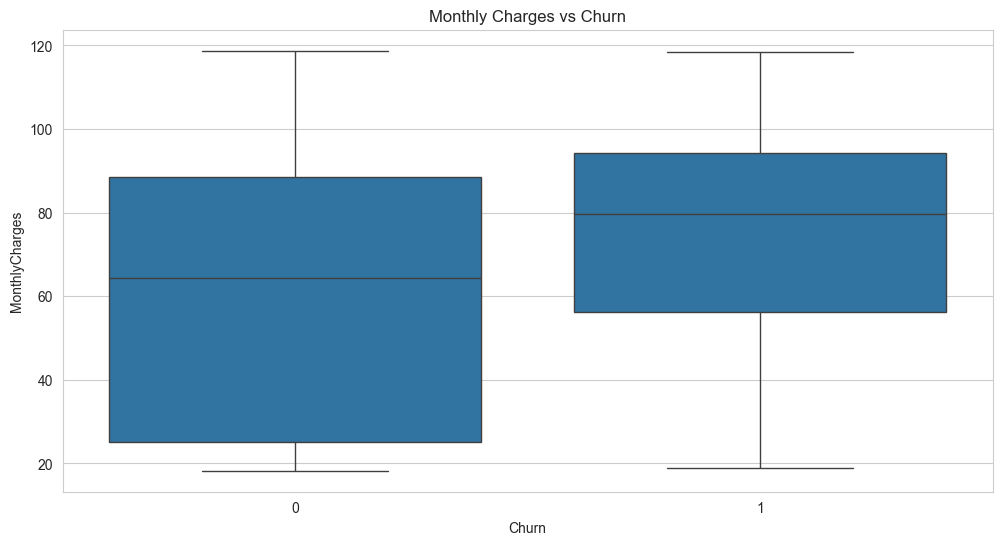

In [56]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges vs Churn")

plt.show()

In [57]:
df_feat = df.copy()

contract_risk = {
    "Month-to-month":3,
    "One year":2,
    "Two year":1
}

df_feat["contract_risk"] = df_feat["Contract"].map(contract_risk)

df_feat["is_high_spender"] = (df_feat["MonthlyCharges"] > 70).astype(int)

df_feat["tenure_risk"] = pd.cut(
    df_feat["tenure"],
    bins=[0,6,12,24,72],
    labels=[3,2,1,0]
).astype(int)

df_feat.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,contract_risk,is_high_spender,tenure_risk
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,3,0,3
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,0,2,0,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3,0,3
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,2,0,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,3,1,3


In [58]:
X = df_feat.drop("Churn", axis=1)

y = df_feat["Churn"]

print(X.shape, y.shape)

(7032, 22) (7032,)


In [59]:
categorical_cols = X.select_dtypes(include="object").columns

print("Categorical columns:", categorical_cols)

Categorical columns: Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [60]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Encoded feature shape:", X.shape)

Encoded feature shape: (7032, 33)


In [61]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5625, 33)
Test shape: (1407, 33)


In [63]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(pd.Series(y_train_res).value_counts())

Churn
0    4130
1    4130
Name: count, dtype: int64


In [64]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_res, y_train_res)

lr_pred = lr_model.predict(X_test)

lr_prob = lr_model.predict_proba(X_test)[:,1]

In [65]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_res, y_train_res)

rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

In [66]:
xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb_model.fit(X_train_res, y_train_res)

xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:,1]

In [67]:
models = ["Logistic Regression","Random Forest","XGBoost"]

accuracy = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, xgb_pred)
]

comparison = pd.DataFrame({
    "Model":models,
    "Accuracy":accuracy
})

comparison

,Model,Accuracy
0,Logistic Regression,0.733475
1,Random Forest,0.768301
2,XGBoost,0.788202


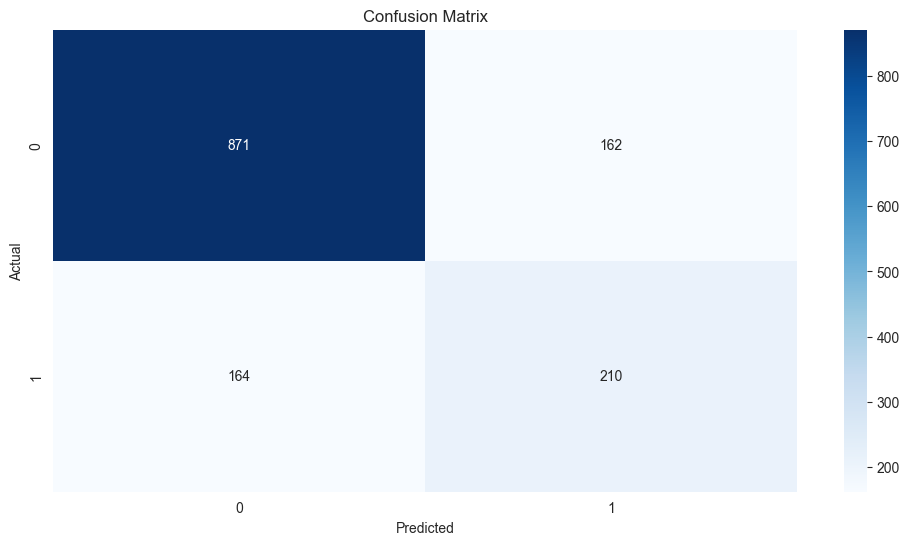

In [68]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

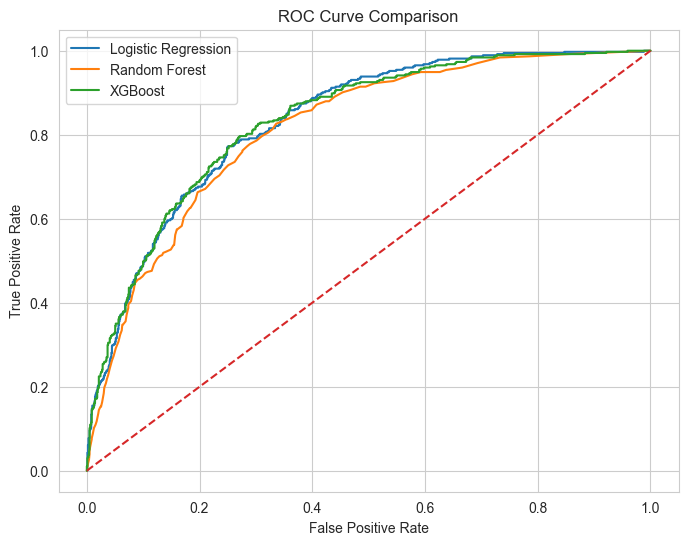

In [69]:
plt.figure(figsize=(8,6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

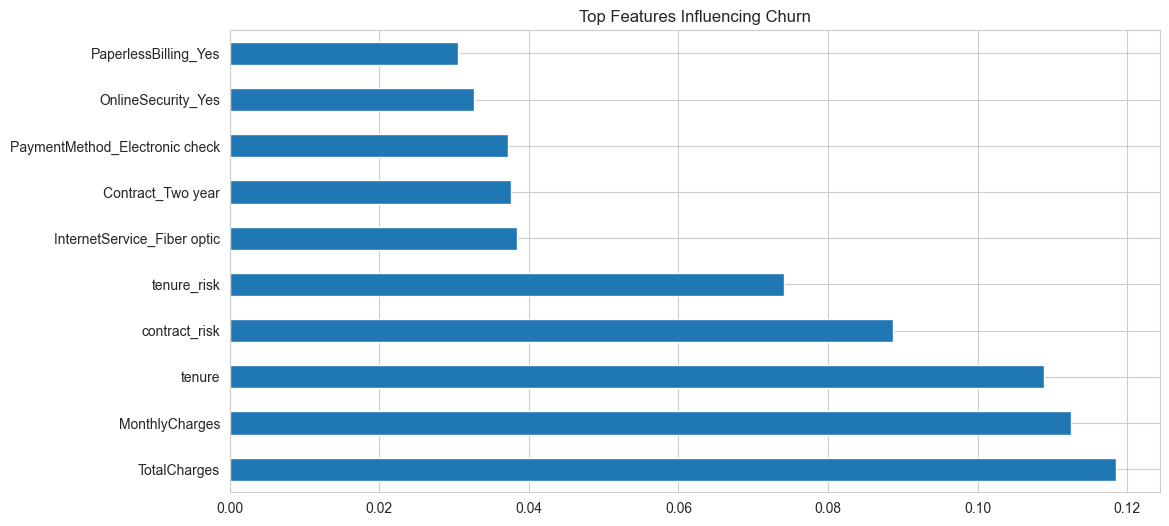

In [70]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns)

top_features = importance.sort_values(ascending=False).head(10)

top_features.plot(kind="barh")

plt.title("Top Features Influencing Churn")

plt.savefig("../images/feature_importance.png")

plt.show()

In [71]:
os.makedirs("../models", exist_ok=True)

joblib.dump(xgb_model, "../models/churn_model.pkl")

joblib.dump(scaler, "../models/scaler.pkl")

print("Model saved successfully")

Model saved successfully


## Conclusion

In this project we built machine learning models to predict customer churn.

Key Findings:
- XGBoost achieved the highest accuracy.
- Contract type and tenure strongly influence churn.
- Customers with month-to-month contracts have higher churn risk.

This model can help businesses identify high-risk customers and improve retention strategies.